# EEG Authentication (ds004148 · Memory task · Fp1 / Fp2 / Fz · 500 Hz)

**Pipeline in this notebook:** preprocessing → features → Track A (LDA + cosine) → Track B (small 1D-CNN embedding) → score fusion → attempt-level verification → FAR / FRR / TAR / **EER**.

**Protocol (3 session permutations, each session is held out once):**

| ID | Enrollment (training + templates) | Verification (authentication) |
|----|-----------------------------------|-------------------------------|
| P1 | S1 + S2 | S3 |
| P2 | S3 + S2 | S1 |
| P3 | S1 + S3 | S2 |

**Leakage rules enforced in code:** the verification session is never used for fitting scalers, PCA/LDA, CNN training, early stopping, fusion weights or templates. Model selection uses a *dev split inside the enrollment sessions* (train on the first enrollment session, validate on the second).

Folder layout expected: `ds004148/sub-XX/ses-sessionN/eeg/sub-XX_ses-sessionN_task-memory_eeg.vhdr`

In [2]:
%pip install torch


   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.1 MB 6.6 MB/s eta 0:00:19
    --------------------------------------- 1.6/124.1 MB 5.7 MB/s eta 0:00:22
    --------------------------------------- 2.9/124.1 MB 5.6 MB/s eta 0:00:22
   - -------------------------------------- 4.2/124.1 MB 5.9 MB/s eta 0:00:21
   - -------------------------------------- 5.2/124.1 MB 5.9 MB/s eta 0:00:21
   -- ------------------------------------- 6.8/124.1 MB 6.0 MB/s eta 0:00:20
   -- ------------------------------------- 8.1/124.1 MB 6.2 MB/s eta 0:00:19
   -- ------------------------------------- 8.9/124.1 MB 5.8 MB/s eta 0:00:20
   --- ------------------------------------ 9.7/124.1 MB 5.6 MB/s eta 0:00:21
   --- ------------------------------------ 10.2/124.1 MB 5.3 MB/s eta 0:00:22
   --- ------------------------------------ 11.0/124.1 MB 5.2 MB/s eta 0:00:22
   --- ------------------------------------ 11.8/124.1 MB 5.0 MB/s et


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ===== 1. Imports =====
# pip install mne scikit-learn scipy pandas matplotlib tqdm torch   (run once, if needed)
import os, copy, json, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore")

In [5]:
# ===== 2. Configuration (freeze before running final evaluation) =====
DATA_ROOT = Path(os.environ.get(
    "EEG_DATA_ROOT",
    r"C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148"))
OUT_ROOT  = DATA_ROOT.parent / "auth_outputs"
WIN_DIR   = OUT_ROOT / "processed_windows_v2"      # preprocessed windows (cached)
RES_DIR   = OUT_ROOT / "results"
for d in (WIN_DIR, RES_DIR):
    d.mkdir(parents=True, exist_ok=True)

TASK      = "memory"
CHANNELS  = ["Fp1", "Fp2", "Fz"]
SFREQ     = 500.0
L_FREQ, H_FREQ = 0.3, 45.0          # band-pass (original reference is kept)
WIN_SEC   = 4                       # -> 2000 samples per window
FP_PTP_UV = 100.0                   # reject window if Fp1 or Fp2 peak-to-peak > this
FLAT_STD_UV = 0.1                   # reject flat-line windows

S1, S2, S3 = "ses-session1", "ses-session2", "ses-session3"
PERMUTATIONS = [
    {"name": "P1: S1+S2 -> S3", "enroll": [S1, S2], "test": S3},
    {"name": "P2: S3+S2 -> S1", "enroll": [S3, S2], "test": S1},
    {"name": "P3: S1+S3 -> S2", "enroll": [S1, S3], "test": S2},
]

MIN_ENROLL_WIN = 10                 # a subject needs >= this many clean windows in EACH enrollment session
K_LIST    = [1, 3, 5, 10]           # windows per authentication attempt (K=5 -> 20 s)
K_PRIMARY = 5                       # headline K (fixed in advance)

# Track A (features + LDA)
PCA_VAR   = 0.99
LDA_DIMS  = 50
# Track B (CNN)
DECIM     = 4                       # 500 Hz -> 125 Hz for the CNN
CROP      = 480                     # samples fed to CNN (random crop in training, centre crop at test)
EMB_DIM   = 64
MAX_EPOCHS = int(os.environ.get("EEG_MAX_EPOCHS", 60))
PATIENCE  = 10
BATCH     = 128
LR        = 2e-3
N_BOOT    = 300                     # subject-level bootstrap resamples for EER confidence intervals
FUSION_W  = 0.5                     # weight of Track A in score fusion (fixed in advance). None = pick on dev split.

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| data root exists:", DATA_ROOT.exists())

Device: cpu | data root exists: True


## 3. Preprocessing
Load BrainVision → keep only Fp1/Fp2/Fz (raw files are never edited) → 0.3–45 Hz FIR band-pass → 4 s non-overlapping windows → reject windows with NaN/Inf, flat-line, or Fp1/Fp2 peak-to-peak above the threshold.
Windows are saved in µV together with their original window index (needed to keep temporal order for attempts).

In [6]:
# ===== 3a. Single-recording preprocessing =====
def preprocess_recording(vhdr_file):
    raw = mne.io.read_raw_brainvision(vhdr_file, preload=False, verbose=False)
    missing = [c for c in CHANNELS if c not in raw.ch_names]
    if missing:
        raise ValueError(f"Missing channels {missing}")
    raw.pick(CHANNELS)
    raw.reorder_channels(CHANNELS)          # guarantee Fp1, Fp2, Fz order
    raw.load_data()
    if abs(raw.info["sfreq"] - SFREQ) > 1e-6:
        raise ValueError(f"Unexpected sfreq {raw.info['sfreq']}")
    raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, fir_design="firwin", verbose=False)

    data = raw.get_data() * 1e6                          # volts -> microvolts, (3, n_samples)
    win = int(WIN_SEC * SFREQ)
    n_win = data.shape[1] // win
    w = data[:, :n_win * win].reshape(3, n_win, win).transpose(1, 0, 2)   # (n_win, 3, win)

    ptp = np.ptp(w, axis=2)
    std = w.std(axis=2)
    finite = np.isfinite(w).all(axis=(1, 2))
    artifact = (ptp[:, 0] > FP_PTP_UV) | (ptp[:, 1] > FP_PTP_UV)
    flat = (std < FLAT_STD_UV).any(axis=1)
    keep = finite & ~artifact & ~flat

    info = dict(total_windows=int(n_win), accepted=int(keep.sum()),
                rejected=int((~keep).sum()), n_artifact=int(artifact.sum()),
                n_flat=int(flat.sum()), n_nonfinite=int((~finite).sum()))
    return w[keep].astype(np.float32), np.where(keep)[0].astype(np.int32), info

In [7]:
# ===== 3b. Batch preprocessing (cached: set OVERWRITE=True to redo) =====
OVERWRITE = False

def run_preprocessing(overwrite=OVERWRITE):
    vhdr_files = sorted(DATA_ROOT.glob(f"sub-*/ses-*/eeg/*task-{TASK}_eeg.vhdr"))
    print("Memory recordings found:", len(vhdr_files))
    rows = []
    for f in tqdm(vhdr_files, desc="Preprocessing"):
        sub, ses = f.parts[-4], f.parts[-3]
        out = WIN_DIR / f"{sub}_{ses}.npz"
        try:
            if out.exists() and not overwrite:
                z = np.load(out)
                info = dict(total_windows=int(z["total_windows"]), accepted=len(z["windows"]))
                info["rejected"] = info["total_windows"] - info["accepted"]
            else:
                w, idx, info = preprocess_recording(f)
                np.savez_compressed(out, windows=w, window_idx=idx,
                                    sfreq=SFREQ, total_windows=info["total_windows"])
            rows.append(dict(subject=sub, session=ses, **info,
                             rejection_rate=info["rejected"] / max(info["total_windows"], 1), error=None))
        except Exception as e:
            print(f"ERROR {sub} {ses}: {e}")
            rows.append(dict(subject=sub, session=ses, error=str(e)))
    man = pd.DataFrame(rows)
    man.to_csv(RES_DIR / "preprocessing_manifest.csv", index=False)
    return man

manifest = run_preprocessing()
print("Recordings processed:", manifest["error"].isna().sum(), "/", len(manifest))
print(manifest[["total_windows", "accepted", "rejected", "rejection_rate"]].describe().round(3))
print("\nRejection rate by session:")
print(manifest.groupby("session")[["total_windows", "accepted", "rejected"]].sum()
      .assign(rate=lambda d: (d.rejected / d.total_windows).round(3)))
print("\nRecordings with fewer than", MIN_ENROLL_WIN, "clean windows:")
print(manifest[manifest["accepted"] < MIN_ENROLL_WIN][["subject", "session", "accepted"]].to_string(index=False))

Memory recordings found: 180


Preprocessing:   0%|          | 0/180 [00:00<?, ?it/s]

Recordings processed: 180 / 180
       total_windows  accepted  rejected  rejection_rate
count        180.000   180.000   180.000         180.000
mean          74.978    48.528    26.450           0.353
std            0.298    21.363    21.326           0.285
min           71.000     0.000     1.000           0.013
25%           75.000    36.000     7.000           0.093
50%           75.000    53.000    22.000           0.293
75%           75.000    68.000    39.000           0.520
max           75.000    74.000    75.000           1.000

Rejection rate by session:
              total_windows  accepted  rejected   rate
session                                               
ses-session1           4500      3060      1440  0.320
ses-session2           4500      3040      1460  0.324
ses-session3           4496      2635      1861  0.414

Recordings with fewer than 10 clean windows:
subject      session  accepted
 sub-02 ses-session3         1
 sub-11 ses-session1         1
 sub-11 ses-s

In [8]:
# ===== 3c. Load all cached windows =====
WIN = {}                                 # (subject, session) -> (n_windows, 3, 2000) float32, µV
for f in sorted(WIN_DIR.glob("sub-*_ses-*.npz")):
    z = np.load(f)
    sub, ses = f.stem.split("_", 1)
    WIN[(sub, ses)] = z["windows"]
SUBJECTS = sorted({k[0] for k in WIN})
n_of = lambda key: len(WIN.get(key, []))
print(f"{len(SUBJECTS)} subjects | {len(WIN)} recordings | "
      f"{sum(len(v) for v in WIN.values())} clean windows | window shape {next(iter(WIN.values())).shape[1:]}")

60 subjects | 180 recordings | 8735 clean windows | window shape (3, 2000)


## 4. Features (Track A input)
Per 4 s window and per channel: **log-PSD in 1 Hz bins (1–45 Hz)** (Welch), **frequency-weighted-power centroid** per band (FWP ÷ band power, amplitude-invariant), **log relative band power**, plus **log Hjorth mobility / complexity**.
Total = 3 × (44 + 5 + 5 + 2) = 168 features. Cross-channel log-ratios are linear combinations of the log features, so the LDA stage can learn them.

In [9]:
# ===== 4. Feature extraction =====
BANDS = {"delta": (1, 4), "theta": (4, 8), "alpha": (8, 13), "beta": (13, 30), "gamma": (30, 45)}

def extract_features(win):                                   # win: (n, 3, T) in µV
    n = len(win)
    f, P = signal.welch(win, fs=SFREQ, nperseg=1000, noverlap=500, axis=-1)   # (n, 3, 501)
    bins = [P[..., (f >= lo) & (f < lo + 1)].mean(-1) for lo in range(1, 45)]
    logpsd = np.log10(np.stack(bins, -1) + 1e-12)           # (n, 3, 44)

    tot = P[..., (f >= 1) & (f < 45)].sum(-1)
    cen, rel = [], []
    for lo, hi in BANDS.values():
        m = (f >= lo) & (f < hi)
        pb, fb = P[..., m], f[m]
        cen.append((pb * fb).sum(-1) / (pb.sum(-1) + 1e-12))                  # FWP / band power
        rel.append(np.log10(pb.sum(-1) / (tot + 1e-12) + 1e-12))
    cen, rel = np.stack(cen, -1), np.stack(rel, -1)         # (n, 3, 5)

    dx, ddx = np.diff(win, axis=-1), np.diff(win, n=2, axis=-1)
    v0, v1, v2 = win.var(-1) + 1e-12, dx.var(-1) + 1e-12, ddx.var(-1) + 1e-12
    mob = np.sqrt(v1 / v0); comp = np.sqrt(v2 / v1) / mob
    return np.concatenate([logpsd.reshape(n, -1), cen.reshape(n, -1), rel.reshape(n, -1),
                           np.log(mob), np.log(comp)], axis=1).astype(np.float32)

FEAT = {k: extract_features(v) for k, v in tqdm(WIN.items(), desc="Features") if len(v)}
print("Feature dimension:", next(iter(FEAT.values())).shape[1])

Features:   0%|          | 0/180 [00:00<?, ?it/s]

Feature dimension: 168


## 5. CNN input (Track B)
Down-sample 500 → 125 Hz (data are already low-passed at 45 Hz), then z-score every window per channel (removes session gain/impedance differences).

In [10]:
# ===== 5. CNN inputs =====
def prep_cnn(win):
    x = signal.decimate(win.astype(np.float64), DECIM, axis=-1, zero_phase=True)
    x = (x - x.mean(-1, keepdims=True)) / (x.std(-1, keepdims=True) + 1e-8)
    return x.astype(np.float32)                              # (n, 3, 500)

CNNX = {k: prep_cnn(v) for k, v in tqdm(WIN.items(), desc="CNN inputs") if len(v)}
print("CNN input shape per window:", next(iter(CNNX.values())).shape[1:])

CNN inputs:   0%|          | 0/180 [00:00<?, ?it/s]

CNN input shape per window: (3, 500)


## 6. Metrics
FAR / FRR / TAR / EER from genuine and impostor scores. Scores are attempt-level cosine similarities. Confidence intervals come from a **subject-level bootstrap** (windows/attempts of one subject are not independent).

In [11]:
# ===== 6. Biometric metrics =====
def eer_from_scores(gen, imp):
    y = np.r_[np.ones(len(gen)), np.zeros(len(imp))]
    s = np.r_[gen, imp]
    fpr, tpr, thr = roc_curve(y, s)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[i] + fnr[i]) / 2), float(thr[i]), fpr, tpr

def tar_at_far(fpr, tpr, far):
    return float(np.interp(far, fpr, tpr))

def split_scores(S, y):
    # S: (n_attempts, n_claims) cosine matrix; y: true subject index of each attempt
    G = y[:, None] == np.arange(S.shape[1])[None, :]
    return S[G], S[~G]

def evaluate_scores(S, y, n_boot=N_BOOT, seed=0):
    gen, imp = split_scores(S, y)
    if len(gen) == 0 or len(imp) == 0:
        return None
    eer, thr, fpr, tpr = eer_from_scores(gen, imp)
    # subject-level bootstrap over claimed identities
    n_subj = S.shape[1]
    gen_c = [S[y == c, c] for c in range(n_subj)]
    imp_c = [S[y != c, c] for c in range(n_subj)]
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n_subj, n_subj)
        g = np.concatenate([gen_c[i] for i in idx]); m = np.concatenate([imp_c[i] for i in idx])
        if len(g) and len(m):
            boots.append(eer_from_scores(g, m)[0])
    lo, hi = (np.percentile(boots, [2.5, 97.5]) if boots else (np.nan, np.nan))
    return dict(EER=eer, EER_lo=float(lo), EER_hi=float(hi), thr_at_EER=thr,
                TAR_at_FAR_1pct=tar_at_far(fpr, tpr, 0.01),
                TAR_at_FAR_0p1pct=tar_at_far(fpr, tpr, 0.001),
                n_genuine=len(gen), n_impostor=len(imp), fpr=fpr, tpr=tpr, gen=gen, imp=imp)

# --- sanity test on synthetic scores (should give EER close to the analytic value) ---
_rng = np.random.default_rng(0)
_g, _i = _rng.normal(1, 1, 5000), _rng.normal(-1, 1, 5000)
print("Synthetic check EER (expected ~0.159):", round(eer_from_scores(_g, _i)[0], 3))

Synthetic check EER (expected ~0.159): 0.161


## 7. Embedding utilities, templates and attempt-level scoring
* **Template** of a subject = mean of the L2-normalised window embeddings of each enrollment session, averaged over the two enrollment sessions.
* **Attempt** = mean embedding of K consecutive clean windows from the verification session.
* **Genuine trial:** attempt of subject *s* vs template of *s*. **Impostor trial:** attempt of subject *t ≠ s* vs template of *s*.

In [12]:
# ===== 7. Templates and attempts =====
def l2n(x, axis=-1):
    return x / (np.linalg.norm(x, axis=axis, keepdims=True) + 1e-12)

def embed_keys(embedder, SRC, keys):
    return {k: embedder(SRC[k]) for k in keys if k in SRC}

def make_templates(E, subj, sessions):
    T = []
    for s in subj:
        per_ses = [l2n(E[(s, e)]).mean(0) for e in sessions]
        T.append(l2n(np.mean(per_ses, 0)))
    return np.stack(T)

def make_attempts(E, subj, session, K):
    A, y = [], []
    for i, s in enumerate(subj):
        X = E.get((s, session))
        if X is None or len(X) < K:
            continue
        X = l2n(X)
        for a in range(len(X) // K):
            A.append(X[a * K:(a + 1) * K].mean(0)); y.append(i)
    return l2n(np.array(A)), np.array(y)

def score_matrix(E, subj, enroll, test, K):
    T = make_templates(E, subj, enroll)
    A, y = make_attempts(E, subj, test, K)
    return A @ T.T, y

## 8. Track A — spectral features → scaler → PCA → LDA → cosine
LDA is fit on the enrollment sessions with subject labels. Because the enrollment windows come from two different sessions, between-session shift is part of the *within-subject* variance, which LDA learns to suppress.

In [13]:
# ===== 8. Track A =====
def fit_track_A(subj, sessions):
    X = np.concatenate([FEAT[(s, e)] for s in subj for e in sessions if (s, e) in FEAT])
    y = np.concatenate([[i] * len(FEAT[(s, e)]) for i, s in enumerate(subj)
                        for e in sessions if (s, e) in FEAT])
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)
    pca = PCA(n_components=PCA_VAR, svd_solver="full").fit(Xs)
    Xp = pca.transform(Xs)
    n_comp = min(LDA_DIMS, len(subj) - 1, Xp.shape[1])
    lda = LinearDiscriminantAnalysis(solver="eigen", shrinkage="auto", n_components=n_comp).fit(Xp, y)
    embedder = lambda F_: l2n(lda.transform(pca.transform(scaler.transform(F_))))
    return embedder, FEAT

## 9. Track B — small 1D-CNN embedding
Pyramidal CNN (~74k parameters, filters 64→32→32→16), SELU + BatchNorm, dropout 0.3, trained as a 60-way subject classifier; the 64-d layer before the classifier is the embedding. Class-balanced sampling, label smoothing, random-crop + noise augmentation.
Early stopping uses a **session-held-out dev split** (train on the first enrollment session, validate on the second); the final model is retrained on both enrollment sessions for the chosen number of epochs.

In [14]:
# ===== 9. Track B =====
class EmbedNet(nn.Module):
    def __init__(self, n_classes, emb_dim=EMB_DIM, in_ch=3, crop=CROP):
        super().__init__()
        def blk(i, o, k):
            return nn.Sequential(nn.Conv1d(i, o, k, padding=k // 2), nn.BatchNorm1d(o),
                                 nn.SELU(), nn.MaxPool1d(2))
        self.features = nn.Sequential(blk(in_ch, 64, 5), blk(64, 32, 5), blk(32, 32, 3), blk(32, 16, 3))
        flat = 16 * (crop // 16)
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(flat, 100), nn.SELU(), nn.Dropout(0.3))
        self.emb = nn.Linear(100, emb_dim)
        self.drop = nn.Dropout(0.3)
        self.cls = nn.Linear(emb_dim, n_classes)
    def embed(self, x):
        return self.emb(self.fc(self.features(x)))
    def forward(self, x):
        return self.cls(self.drop(self.embed(x)))

print("CNN parameters:", sum(p.numel() for p in EmbedNet(60).parameters()))

def random_crop(x):
    B, C, T = x.shape
    off = torch.randint(0, T - CROP + 1, (B,), device=x.device)
    idx = off[:, None] + torch.arange(CROP, device=x.device)[None, :]
    return x[torch.arange(B, device=x.device)[:, None, None],
             torch.arange(C, device=x.device)[None, :, None], idx[:, None, :]]

def center_crop(x):
    o = (x.shape[-1] - CROP) // 2
    return x[..., o:o + CROP]

@torch.no_grad()
def cnn_embed(model, X, bs=512):
    model.eval(); out = []
    for i in range(0, len(X), bs):
        xb = center_crop(torch.from_numpy(X[i:i + bs]).to(DEVICE))
        out.append(model.embed(xb).cpu().numpy())
    return np.concatenate(out)

def train_cnn(Xtr, ytr, n_classes, Xva=None, yva=None, epochs=None, seed=SEED):
    set_seed(seed)
    model = EmbedNet(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    max_ep = epochs if epochs is not None else MAX_EPOCHS
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_ep)
    Xt = torch.from_numpy(Xtr).to(DEVICE); yt = torch.from_numpy(ytr).long().to(DEVICE)
    counts = np.bincount(ytr, minlength=n_classes).astype(float)
    sample_w = torch.from_numpy(1.0 / counts[ytr]).double()
    sampler = torch.utils.data.WeightedRandomSampler(sample_w, num_samples=len(ytr), replacement=True)
    best = dict(acc=-1, loss=1e9, ep=0, state=None)
    stale = 0
    for ep in range(1, max_ep + 1):
        model.train()
        for idx in torch.utils.data.BatchSampler(sampler, BATCH, drop_last=False):
            idx = torch.as_tensor(idx, device=DEVICE)
            xb = random_crop(Xt[idx]); xb = xb + 0.1 * torch.randn_like(xb)
            loss = F.cross_entropy(model(xb), yt[idx], label_smoothing=0.1)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        if Xva is not None:
            model.eval()
            with torch.no_grad():
                xv = center_crop(torch.from_numpy(Xva).to(DEVICE)); yv = torch.from_numpy(yva).long().to(DEVICE)
                logits = model(xv); vloss = F.cross_entropy(logits, yv).item()
                vacc = (logits.argmax(1) == yv).float().mean().item()
            if vacc > best["acc"] or (vacc == best["acc"] and vloss < best["loss"]):
                best.update(acc=vacc, loss=vloss, ep=ep, state=copy.deepcopy(model.state_dict())); stale = 0
            else:
                stale += 1
                if stale >= PATIENCE:
                    break
    if Xva is not None:
        model.load_state_dict(best["state"])
        return model, best["ep"], best["acc"]
    return model, max_ep, None

def stack_xy(subj, sessions, SRC):
    X = np.concatenate([SRC[(s, e)] for s in subj for e in sessions if (s, e) in SRC])
    y = np.concatenate([[i] * len(SRC[(s, e)]) for i, s in enumerate(subj)
                        for e in sessions if (s, e) in SRC])
    return X, y

def fit_track_B(subj, train_sessions, val_sessions=None, epochs=None):
    Xtr, ytr = stack_xy(subj, train_sessions, CNNX)
    if val_sessions:
        Xva, yva = stack_xy(subj, val_sessions, CNNX)
        model, best_ep, vacc = train_cnn(Xtr, ytr, len(subj), Xva, yva)
    else:
        model, best_ep, vacc = train_cnn(Xtr, ytr, len(subj), epochs=epochs)
    return (lambda X_: cnn_embed(model, X_)), best_ep, vacc

CNN parameters: 74704


## 10. Run the three session permutations
For each permutation:
1. **Dev stage** (inside the enrollment sessions only): fit on the first enrollment session, test on the second → gives the CNN epoch count and the score-normalisation statistics used for fusion. *Dev EER for Track A is pessimistic* (LDA sees only one session, so it cannot learn between-session shift); that is why the fusion weight is fixed in advance (`FUSION_W = 0.5`) instead of being picked on dev.
2. **Final stage:** refit on both enrollment sessions, build templates, authenticate on the untouched verification session.

In [15]:
# ===== 10. Experiment runner =====
def fuse(SA, SB, stats, w):
    za = (SA - stats["muA"]) / stats["sdA"]; zb = (SB - stats["muB"]) / stats["sdB"]
    return w * za + (1 - w) * zb

def run_permutation(perm):
    enroll, test = perm["enroll"], perm["test"]
    subj = [s for s in SUBJECTS if all(n_of((s, e)) >= MIN_ENROLL_WIN for e in enroll)]
    print(f"\n=== {perm['name']} | enrolled subjects: {len(subj)} / {len(SUBJECTS)} ===")
    dev_tr, dev_te = [enroll[0]], enroll[1]

    # ---------- DEV STAGE (verification session is NOT touched) ----------
    embA, SRC_A = fit_track_A(subj, dev_tr)
    EA = embed_keys(embA, SRC_A, [(s, e) for s in subj for e in (dev_tr[0], dev_te)])
    embB, best_ep, vacc = fit_track_B(subj, dev_tr, val_sessions=[dev_te])
    EB = embed_keys(embB, CNNX, [(s, e) for s in subj for e in (dev_tr[0], dev_te)])
    print(f"  CNN dev: best epoch {best_ep}, val acc {vacc:.3f}")
    SA_d, y_d = score_matrix(EA, subj, dev_tr, dev_te, K_PRIMARY)
    SB_d, _   = score_matrix(EB, subj, dev_tr, dev_te, K_PRIMARY)
    stats = dict(muA=SA_d.mean(), sdA=SA_d.std() + 1e-9, muB=SB_d.mean(), sdB=SB_d.std() + 1e-9)
    dev_rows = []
    best_w = FUSION_W if FUSION_W is not None else 0.5
    if FUSION_W is None:                      # optional: select weight on the dev split
        best_eer = 9
        for w in np.round(np.arange(0, 1.01, 0.1), 1):
            r = evaluate_scores(fuse(SA_d, SB_d, stats, w), y_d, n_boot=0)
            if r and r["EER"] < best_eer - 1e-12:
                best_eer, best_w = r["EER"], float(w)
    for name, S in [("A", SA_d), ("B", SB_d), ("Fusion", fuse(SA_d, SB_d, stats, best_w))]:
        r = evaluate_scores(S, y_d, n_boot=0)
        dev_rows.append(dict(permutation=perm["name"], model=name, K=K_PRIMARY, dev_EER=r["EER"], fusion_w_A=best_w))
    print(f"  Dev EER (K={K_PRIMARY}): " + " | ".join(f"{d['model']}={d['dev_EER']:.3f}" for d in dev_rows)
          + f" | fusion weight on A = {best_w}")
    print("  (dev understates Track A: LDA sees only ONE session here, so it cannot learn session shift)")

    # ---------- FINAL STAGE ----------
    embA, SRC_A = fit_track_A(subj, enroll)
    keys = [(s, e) for s in subj for e in enroll] + [(s, test) for s in subj]
    EA = embed_keys(embA, SRC_A, keys)
    embB, _, _ = fit_track_B(subj, enroll, epochs=best_ep)
    EB = embed_keys(embB, CNNX, keys)

    rows, store = [], {}
    for K in K_LIST:
        SA, y = score_matrix(EA, subj, enroll, test, K)
        SB, _ = score_matrix(EB, subj, enroll, test, K)
        for name, S in [("A: spectral+LDA", SA), ("B: CNN", SB), ("Fusion A+B", fuse(SA, SB, stats, best_w))]:
            r = evaluate_scores(S, y)
            if r is None:
                continue
            rows.append(dict(permutation=perm["name"], model=name, K=K, n_subjects=len(subj),
                             n_genuine=r["n_genuine"], n_impostor=r["n_impostor"],
                             EER=r["EER"], EER_CI_lo=r["EER_lo"], EER_CI_hi=r["EER_hi"],
                             TAR_at_FAR_1pct=r["TAR_at_FAR_1pct"], TAR_at_FAR_0p1pct=r["TAR_at_FAR_0p1pct"]))
            if K == K_PRIMARY:
                store[name] = r
    return rows, dev_rows, store

all_rows, all_dev, STORE = [], [], {}
t0 = time.time()
for perm in PERMUTATIONS:
    rows, dev_rows, store = run_permutation(perm)
    all_rows += rows; all_dev += dev_rows; STORE[perm["name"]] = store
print(f"\nDone in {(time.time() - t0) / 60:.1f} min")


=== P1: S1+S2 -> S3 | enrolled subjects: 55 / 60 ===
  CNN dev: best epoch 28, val acc 0.531
  Dev EER (K=5): A=0.064 | B=0.070 | Fusion=0.049 | fusion weight on A = 0.5
  (dev understates Track A: LDA sees only ONE session here, so it cannot learn session shift)

=== P2: S3+S2 -> S1 | enrolled subjects: 52 / 60 ===
  CNN dev: best epoch 25, val acc 0.145
  Dev EER (K=5): A=0.170 | B=0.349 | Fusion=0.224 | fusion weight on A = 0.5
  (dev understates Track A: LDA sees only ONE session here, so it cannot learn session shift)

=== P3: S1+S3 -> S2 | enrolled subjects: 51 / 60 ===
  CNN dev: best epoch 35, val acc 0.148
  Dev EER (K=5): A=0.178 | B=0.368 | Fusion=0.223 | fusion weight on A = 0.5
  (dev understates Track A: LDA sees only ONE session here, so it cannot learn session shift)

Done in 24.4 min


## 11. Results

In [16]:
# ===== 11a. Result tables =====
results = pd.DataFrame(all_rows)
dev_results = pd.DataFrame(all_dev)
results.to_csv(RES_DIR / "results_per_permutation.csv", index=False)
dev_results.to_csv(RES_DIR / "dev_results.csv", index=False)

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
print(f"Per-permutation results at K={K_PRIMARY} windows/attempt ({K_PRIMARY * WIN_SEC} s):")
print(results[results.K == K_PRIMARY].round(4).to_string(index=False))

summary = (results.groupby(["model", "K"])
           .agg(mean_EER=("EER", "mean"), median_EER=("EER", "median"), worst_EER=("EER", "max"),
                mean_TAR_at_FAR_1pct=("TAR_at_FAR_1pct", "mean"),
                mean_TAR_at_FAR_0p1pct=("TAR_at_FAR_0p1pct", "mean")).round(4).reset_index())
summary.to_csv(RES_DIR / "results_summary.csv", index=False)
print("\nSummary across the 3 permutations (mean / median / worst EER):")
print(summary.to_string(index=False))

Per-permutation results at K=5 windows/attempt (20 s):
    permutation           model  K  n_subjects  n_genuine  n_impostor    EER  EER_CI_lo  EER_CI_hi  TAR_at_FAR_1pct  TAR_at_FAR_0p1pct
P1: S1+S2 -> S3 A: spectral+LDA  5          55        485       26190 0.1464     0.1119     0.1997           0.4495             0.2186
P1: S1+S2 -> S3          B: CNN  5          55        485       26190 0.3301     0.2637     0.3839           0.2454             0.1299
P1: S1+S2 -> S3      Fusion A+B  5          55        485       26190 0.2002     0.1520     0.2511           0.3546             0.1938
P2: S3+S2 -> S1 A: spectral+LDA  5          52        546       27846 0.0608     0.0437     0.0783           0.8059             0.6154
P2: S3+S2 -> S1          B: CNN  5          52        546       27846 0.0910     0.0640     0.1273           0.5989             0.3370
P2: S3+S2 -> S1      Fusion A+B  5          52        546       27846 0.0545     0.0373     0.0779           0.8443             0.6667


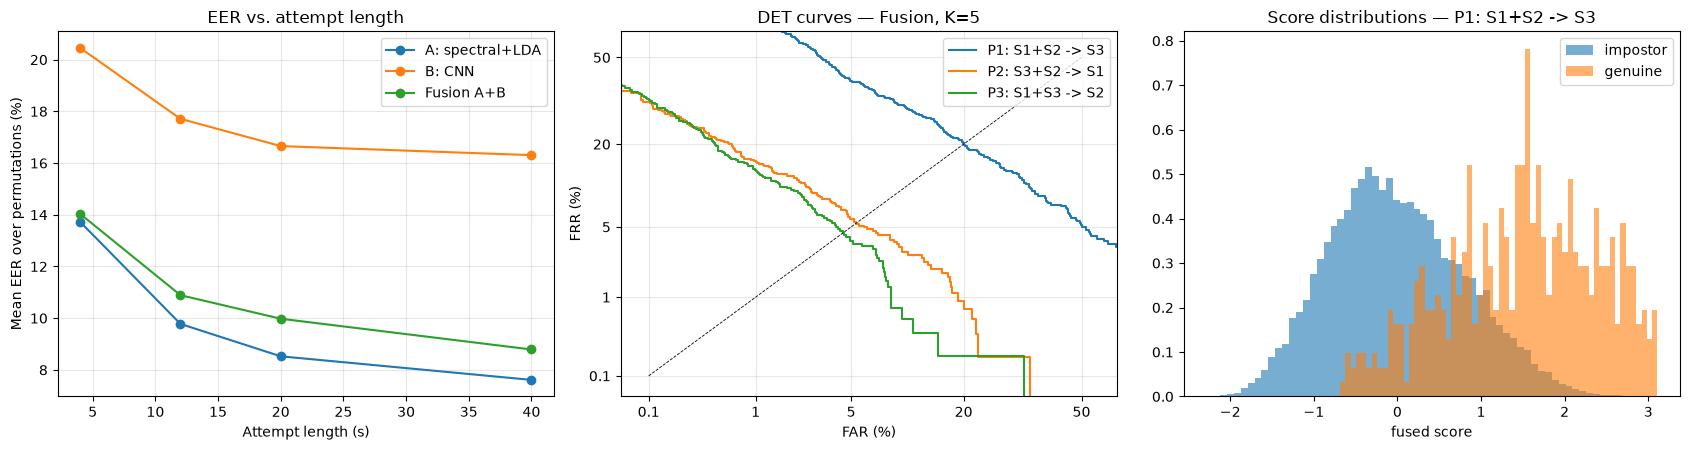

In [17]:
# ===== 11b. EER vs. attempt length, DET curves, score distributions =====
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

for model in results.model.unique():
    d = results[results.model == model].groupby("K").EER.mean()
    ax[0].plot(d.index * WIN_SEC, d.values * 100, marker="o", label=model)
ax[0].set_xlabel("Attempt length (s)"); ax[0].set_ylabel("Mean EER over permutations (%)")
ax[0].set_title("EER vs. attempt length"); ax[0].legend(); ax[0].grid(alpha=.3)

ppf = lambda p: norm.ppf(np.clip(p, 1e-4, 1 - 1e-4))
for pname, store in STORE.items():
    r = store.get("Fusion A+B")
    if r is None: continue
    ax[1].plot(ppf(r["fpr"]), ppf(1 - r["tpr"]), label=pname)
ticks = np.array([0.001, 0.01, 0.05, 0.2, 0.5])
ax[1].set_xticks(ppf(ticks)); ax[1].set_xticklabels([f"{t*100:g}" for t in ticks])
ax[1].set_yticks(ppf(ticks)); ax[1].set_yticklabels([f"{t*100:g}" for t in ticks])
ax[1].plot(ppf(ticks), ppf(ticks), "k--", lw=.6)
ax[1].set_xlim(ppf(5e-4), ppf(0.6)); ax[1].set_ylim(ppf(5e-4), ppf(0.6))
ax[1].set_xlabel("FAR (%)"); ax[1].set_ylabel("FRR (%)")
ax[1].set_title(f"DET curves — Fusion, K={K_PRIMARY}"); ax[1].legend(); ax[1].grid(alpha=.3)

first = next(iter(STORE.values()))["Fusion A+B"]
ax[2].hist(first["imp"], bins=60, alpha=.6, density=True, label="impostor")
ax[2].hist(first["gen"], bins=60, alpha=.6, density=True, label="genuine")
ax[2].set_title(f"Score distributions — {list(STORE)[0]}"); ax[2].set_xlabel("fused score"); ax[2].legend()
plt.tight_layout(); plt.savefig(RES_DIR / "eer_summary.png", dpi=150); plt.show()

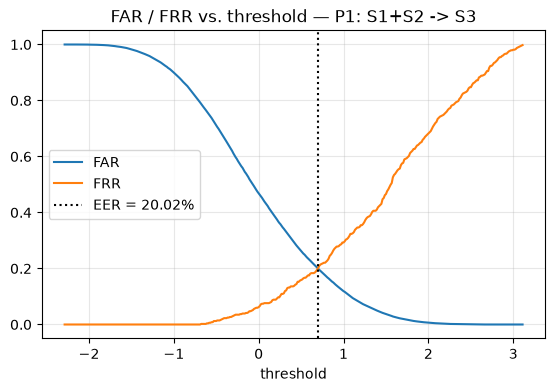

Saved tables, figures and scores to: C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\auth_outputs\results


In [18]:
# ===== 11c. FAR / FRR vs. threshold for one permutation (Fusion, primary K) =====
pname = list(STORE)[0]; r = STORE[pname]["Fusion A+B"]
thr = np.linspace(min(r["imp"].min(), r["gen"].min()), max(r["imp"].max(), r["gen"].max()), 400)
far = [(r["imp"] >= t).mean() for t in thr]; frr = [(r["gen"] < t).mean() for t in thr]
plt.figure(figsize=(6.5, 4)); plt.plot(thr, far, label="FAR"); plt.plot(thr, frr, label="FRR")
plt.axvline(r["thr_at_EER"], color="k", ls=":", label=f"EER = {r['EER']*100:.2f}%")
plt.xlabel("threshold"); plt.title(f"FAR / FRR vs. threshold — {pname}"); plt.legend(); plt.grid(alpha=.3)
plt.savefig(RES_DIR / "far_frr_threshold.png", dpi=150); plt.show()

# Save raw genuine/impostor scores for auditing
np.savez_compressed(RES_DIR / "scores_primary_K.npz",
                    **{f"{p}|{m}|{k}": v[k] for p, s in STORE.items() for m, v in s.items() for k in ("gen", "imp")})
print("Saved tables, figures and scores to:", RES_DIR)

## Notes for interpretation
* **EER is threshold-free and therefore optimistic.** For a deployable operating point choose the threshold on the dev split (or on enrollment data), then report FAR/FRR on the verification session at that fixed threshold.
* Report **all three permutations** (the table shows mean, median and worst), not only the best one.
* The Fusion row uses the pre-declared weight `FUSION_W` (set it to `None` to select the weight on the dev split instead, but remember dev under-rates Track A). Compare A, B and Fusion honestly; if Fusion does not beat the best single track on the verification sessions, say so.
* Subjects with fewer than `MIN_ENROLL_WIN` clean windows in an enrollment session are excluded from that permutation (`n_subjects` column). Subjects with fewer than K clean verification windows contribute no attempts at that K.
* Do not change `FP_PTP_UV`, features or hyper-parameters after looking at verification-session results; if you must, re-run the dev stage and justify the change.